# VPN-Sentinel: Professional End-to-End Notebook

This notebook captures the full VPN-Sentinel workflow: synthetic data generation, exploratory analysis, modeling, robustness testing, explainability, and deployment readiness.

## 1. Project Scope & Setup

The project covers:
- Flow-level VPN vs non-VPN detection
- VPN protocol identification (OpenVPN, WireGuard, IKEv2)
- Browser-level multi-signal classification
- Adversarial traffic shaping evaluation
- SHAP explanation and deployment integration

First, let's import the required libraries and set up our working environment.

In [1]:
import os
import warnings
from pathlib import Path
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import shap
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8')
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
print(f'Working directory: {ROOT}')


Working directory: C:\Users\Vivek\Desktop\vpn sentinel


C:\Users\Vivek\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Generation & Loading

We generate synthetic network flows and browser flows if they do not already exist.
We also apply adversarial traffic shaping to test our model's robustness later.

In [2]:
from data_generator import generate_flows, generate_browser_flows
from adversarial_shaper import apply_evasion
train_flow_path = DATA_DIR / 'train_flows.csv'
test_flow_path = DATA_DIR / 'test_flows.csv'
train_browser_path = DATA_DIR / 'train_browser_flows.csv'
test_browser_path = DATA_DIR / 'test_browser_flows.csv'
adv_test_path = DATA_DIR / 'test_flows_adversarial.csv'
if not all([train_flow_path.exists(), test_flow_path.exists(), train_browser_path.exists(), test_browser_path.exists(), adv_test_path.exists()]):
    print('Generating fresh datasets...')
    flow_df = generate_flows(12000)
    flow_train, flow_test = train_test_split(flow_df, test_size=0.2, random_state=42, stratify=flow_df['is_vpn'])
    flow_train.to_csv(train_flow_path, index=False)
    flow_test.to_csv(test_flow_path, index=False)
    browser_df = generate_browser_flows(8000)
    br_train, br_test = train_test_split(browser_df, test_size=0.2, random_state=42, stratify=browser_df['is_vpn'])
    br_train.to_csv(train_browser_path, index=False)
    br_test.to_csv(test_browser_path, index=False)
    adv_test = apply_evasion(flow_test)
    adv_test.to_csv(adv_test_path, index=False)
train_df = pd.read_csv(train_flow_path)
test_df = pd.read_csv(test_flow_path)
train_br_df = pd.read_csv(train_browser_path)
test_br_df = pd.read_csv(test_browser_path)
test_adv_df = pd.read_csv(adv_test_path)
print(f'Flow train shape: {train_df.shape}')
print(f'Flow test shape: {test_df.shape}')
print(f'Browser train shape: {train_br_df.shape}')


Flow train shape: (24000, 10)
Flow test shape: (6000, 10)
Browser train shape: (12000, 19)


## 3. Exploratory Data Analysis (EDA)

Let's visualize the distribution of labels in our datasets to understand the class balance.

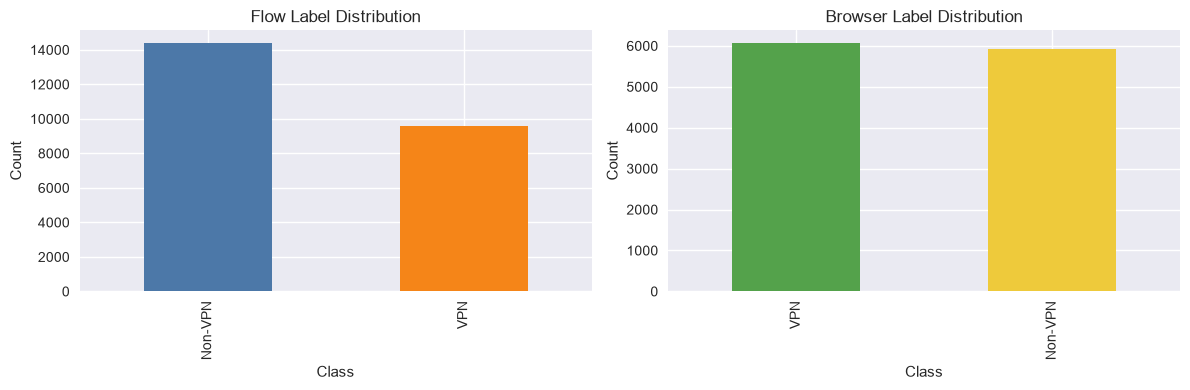

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['is_vpn'].value_counts().rename({0: 'Non-VPN', 1: 'VPN'}).plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('Flow Label Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
train_br_df['is_vpn'].value_counts().rename({0: 'Non-VPN', 1: 'VPN'}).plot(kind='bar', ax=axes[1], color=['#54A24B', '#EECA3B'])
axes[1].set_title('Browser Label Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


## 4. Feature Engineering

We select the relevant features for our models and handle any missing or non-numeric values.
We will prepare data for two stages:
- **Stage 1**: VPN vs Non-VPN detection
- **Stage 2**: VPN Protocol classification (OpenVPN, WireGuard, IKEv2)

In [4]:
flow_features = [
    'duration', 'fwd_pkt_len_mean', 'bwd_pkt_len_mean',
    'flow_iat_mean', 'flow_iat_std', 'jitter_ratio', 'packets_per_sec', 'bytes_per_sec',
    'fwd_pkt_len_max', 'fwd_pkt_len_min', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
    'fwd_pkt_len_std', 'bwd_pkt_len_std', 'flow_iat_max', 'flow_iat_min'
]
browser_features = [
    'duration', 'flow_iat_mean', 'flow_iat_std', 'jitter_ratio', 'packets_per_sec',
    'webrtc_ip_mismatch', 'webrtc_blocked', 'timezone_mismatch_score', 'language_mismatch_score',
    'geo_ip_distance_km', 'has_geo_permission', 'is_datacenter_ip', 'is_known_vpn_ip', 'proxy_header_detected'
]
for df in [train_df, test_df, test_adv_df, train_br_df, test_br_df]:
    for col in flow_features + browser_features:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(-1.0)
X_train_s1 = train_df[flow_features]
y_train_s1 = train_df['is_vpn']
X_test_s1 = test_df[flow_features]
y_test_s1 = test_df['is_vpn']
vpn_train = train_df[train_df['is_vpn'] == 1].copy()
vpn_test = test_df[test_df['is_vpn'] == 1].copy()
X_train_s2 = vpn_train[flow_features]
y_train_s2 = vpn_train['vpn_protocol']
X_test_s2 = vpn_test[flow_features]
y_test_s2 = vpn_test['vpn_protocol']
X_train_br = train_br_df[browser_features]
y_train_br = train_br_df['is_vpn']
X_test_br = test_br_df[browser_features]
y_test_br = test_br_df['is_vpn']
print('Feature preparation complete.')


Feature preparation complete.


## 5. Model Training & Evaluation

First, we analyze the learning curves to see how the model performance grows with the amount of training data.

Stage 1 Growth:
 train_size  accuracy       f1
        250  0.996500 0.996498
        500  0.995500 0.995497
       1000  0.997333 0.997332
       2500  0.997833 0.997833
       5000  0.998500 0.998500

Stage 2 Growth:
 train_size  accuracy       f1
        250  0.950833 0.950733
        500  0.966250 0.966258
       1000  0.969167 0.969066
       2500  0.972917 0.972965
       5000  0.973750 0.973754


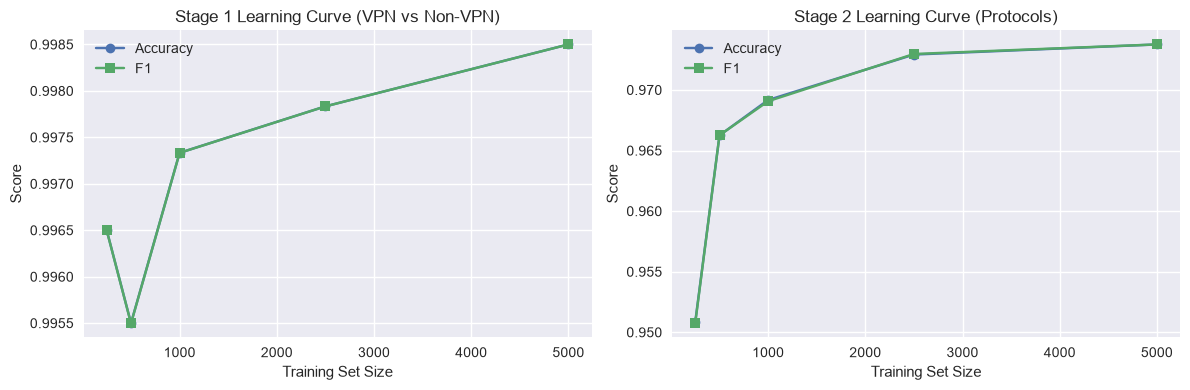

In [5]:
def evaluate_growth(X_train, y_train, X_test, y_test, train_sizes):
    """Evaluates model performance at different training set sizes."""
    rows = []
    for size in train_sizes:
        subset_idx = np.random.choice(len(X_train), size=size, replace=False)
        X_sub = X_train.iloc[subset_idx]
        y_sub = y_train.iloc[subset_idx]
        model = RandomForestClassifier(n_estimators=180, max_depth=12, random_state=42, n_jobs=-1)
        model.fit(X_sub, y_sub)
        pred = model.predict(X_test)
        rows.append({
            'train_size': size, 
            'accuracy': accuracy_score(y_test, pred), 
            'f1': f1_score(y_test, pred, average='weighted')
        })
    return pd.DataFrame(rows)
train_sizes = [250, 500, 1000, 2500, 5000]
growth_s1 = evaluate_growth(X_train_s1, y_train_s1, X_test_s1, y_test_s1, train_sizes)
growth_s2 = evaluate_growth(X_train_s2, y_train_s2, X_test_s2, y_test_s2, train_sizes)
print("Stage 1 Growth:")
print(growth_s1.to_string(index=False))
print('\nStage 2 Growth:')
print(growth_s2.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(growth_s1['train_size'], growth_s1['accuracy'], marker='o', label='Accuracy')
axes[0].plot(growth_s1['train_size'], growth_s1['f1'], marker='s', label='F1')
axes[0].set_title('Stage 1 Learning Curve (VPN vs Non-VPN)')
axes[0].set_xlabel('Training Set Size')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[1].plot(growth_s2['train_size'], growth_s2['accuracy'], marker='o', label='Accuracy')
axes[1].plot(growth_s2['train_size'], growth_s2['f1'], marker='s', label='F1')
axes[1].set_title('Stage 2 Learning Curve (Protocols)')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('Score')
axes[1].legend()
plt.tight_layout()
plt.show()


Next, we train the final models on the full training sets and evaluate their performance. We also export the trained models and feature lists for deployment.

In [6]:
model_s1 = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
model_s1.fit(X_train_s1, y_train_s1)
pred_s1 = model_s1.predict(X_test_s1)
print('=== Stage 1 Report (VPN vs Non-VPN) ===')
print(classification_report(y_test_s1, pred_s1, target_names=['Non-VPN', 'VPN']))
model_s2 = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
model_s2.fit(X_train_s2, y_train_s2)
pred_s2 = model_s2.predict(X_test_s2)
print('\n=== Stage 2 Report (VPN Protocol) ===')
print(classification_report(y_test_s2, pred_s2, target_names=['OpenVPN', 'WireGuard', 'IKEv2']))
model_br_s1 = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
model_br_s1.fit(X_train_br, y_train_br)
pred_br_s1 = model_br_s1.predict(X_test_br)
print('\n=== Browser Model Report ===')
print(classification_report(y_test_br, pred_br_s1, target_names=['Non-VPN', 'VPN']))
joblib.dump(model_s1, MODELS_DIR / 'stage1_model.pkl')
joblib.dump(model_s2, MODELS_DIR / 'stage2_model.pkl')
joblib.dump(model_br_s1, MODELS_DIR / 'browser_stage1_model.pkl')
joblib.dump(flow_features, MODELS_DIR / 'features.pkl')
joblib.dump(browser_features, MODELS_DIR / 'timing_features.pkl')
print('Models and features saved successfully.')


=== Stage 1 Report (VPN vs Non-VPN) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      3600
         VPN       1.00      1.00      1.00      2400

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000




=== Stage 2 Report (VPN Protocol) ===
              precision    recall  f1-score   support

     OpenVPN       0.97      0.96      0.96       931
   WireGuard       1.00      1.00      1.00       988
       IKEv2       0.92      0.94      0.93       481

    accuracy                           0.97      2400
   macro avg       0.96      0.96      0.96      2400
weighted avg       0.97      0.97      0.97      2400




=== Browser Model Report ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      1482
         VPN       1.00      1.00      1.00      1518

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



Models and features saved successfully.


## 6. Adversarial Robustness

We test our trained Stage 1 model against adversarial traffic where malicious actors try to hide VPN signatures by shaping traffic.

In [7]:
X_test_adv_s1 = test_adv_df[flow_features]
y_test_adv_s1 = test_adv_df['is_vpn']
pred_adv_s1 = model_s1.predict(X_test_adv_s1)
clean_acc = accuracy_score(y_test_s1, pred_s1)
adv_acc = accuracy_score(y_test_adv_s1, pred_adv_s1)
print(f'Clean accuracy: {clean_acc:.4f}')
print(f'Adversarial accuracy: {adv_acc:.4f}')
print(f'Performance drop: {clean_acc - adv_acc:.4f}')


Clean accuracy: 0.9990
Adversarial accuracy: 0.9988
Performance drop: 0.0002


## 7. Model Explainability

Finally, we use SHAP (SHapley Additive exPlanations) to understand which features are most important for our model's predictions.

<Figure size 1000x600 with 0 Axes>

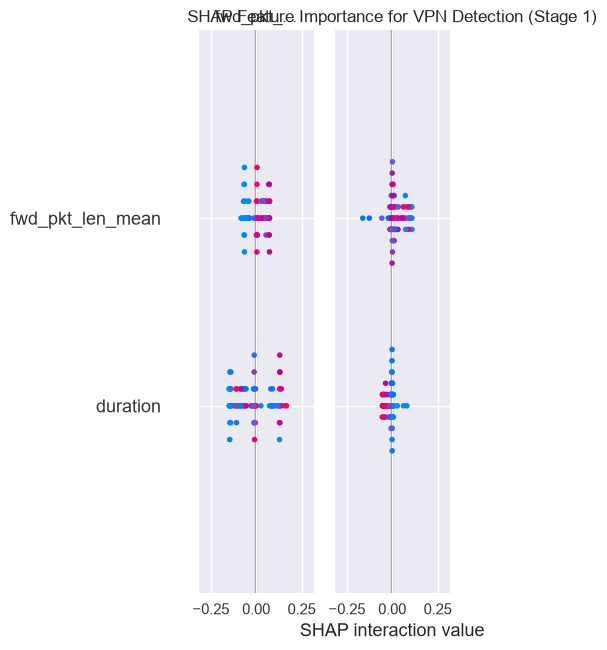

In [8]:
explainer_s1 = shap.TreeExplainer(model_s1)
sample_df = X_test_s1.iloc[:80]
shap_values_s1 = explainer_s1.shap_values(sample_df)
if isinstance(shap_values_s1, list):
    shap_values_s1 = shap_values_s1[1]
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_s1, sample_df, plot_type='bar', show=False)
plt.title('SHAP Feature Importance for VPN Detection (Stage 1)')
plt.tight_layout()
plt.show()


## Conclusion

This notebook presents a professional, end-to-end view of the VPN-Sentinel project. It combines data generation, learning-curve analysis, robust evaluation, SHAP explainability, and deployment-ready artifact export.

## 8. Multi-Model Comparison
Evaluating Decision Tree, Naive Bayes, Random Forest, and AdaBoost classifiers and comparing their Confusion Matrices and ROC curves.

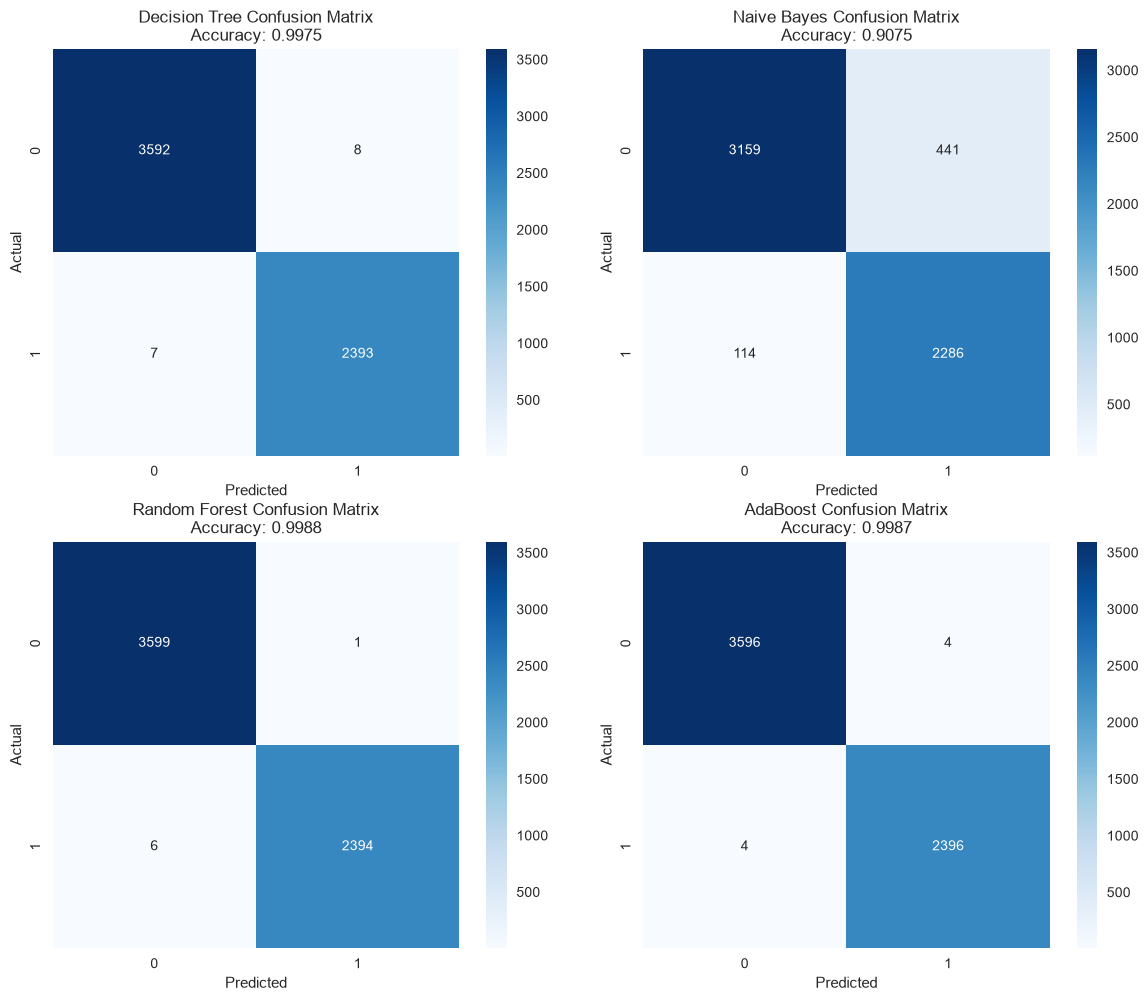

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import RocCurveDisplay
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42)
}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_s1, y_train_s1)
    y_pred = model.predict(X_test_s1)
    cm = confusion_matrix(y_test_s1, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], square=True)
    axes[i].set_title(f'{name} Confusion Matrix\nAccuracy: {accuracy_score(y_test_s1, y_pred):.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()


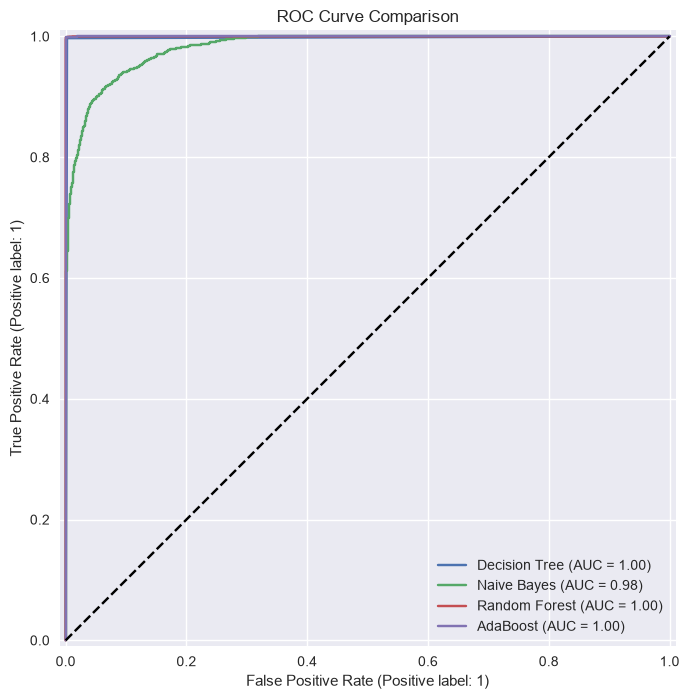

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_s1, y_test_s1, ax=ax, name=name)
ax.plot([0, 1], [0, 1], color='black', linestyle='--')
ax.set_title('ROC Curve Comparison')
plt.show()


## 9. Appendix: Real-World Dataset Preprocessing
This section details the historical data preprocessing, cleaning, and scaling applied to our real-world packet capture dataset (`vpn-non_vpn new data.csv`).

In [11]:
import pandas as pd
raw_data = pd.read_csv("vpn-non_vpn new data.csv")
raw_data.head()


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,131.202.244.5-10.8.0.14-53-36455-17,10.8.0.14,36455.0,131.202.244.5,53.0,17.0,15/04/2015 02:23:50 AM,774.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,vpn
1,131.202.240.150-173.252.79.93-36512-3478-6,131.202.240.150,36512.0,173.252.79.93,3478.0,6.0,30/03/2015 06:12:03 PM,634204.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non_vpn
2,131.202.244.3-10.8.0.10-53-1588-17,10.8.0.10,1588.0,131.202.244.3,53.0,17.0,15/04/2015 01:18:04 AM,903.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,vpn
3,10.8.8.130-94.28.188.85-51413-6881-17,10.8.8.130,51413.0,94.28.188.85,6881.0,17.0,4/6/2015 18:05,207853.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,vpn
4,10.8.8.138-74.125.226.33-41347-443-6,10.8.8.138,41347.0,74.125.226.33,443.0,6.0,23/05/2015 01:19:08 AM,222081.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,vpn


In [12]:
raw_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 84 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Flow ID            18086 non-null  str    
 1   Src IP             18086 non-null  str    
 2   Src Port           18086 non-null  float64
 3   Dst IP             18086 non-null  str    
 4   Dst Port           18086 non-null  float64
 5   Protocol           18086 non-null  float64
 6   Timestamp          18086 non-null  str    
 7   Flow Duration      18086 non-null  float64
 8   Tot Fwd Pkts       18086 non-null  float64
 9   Tot Bwd Pkts       18086 non-null  float64
 10  TotLen Fwd Pkts    18086 non-null  float64
 11  TotLen Bwd Pkts    18086 non-null  float64
 12  Fwd Pkt Len Max    18086 non-null  float64
 13  Fwd Pkt Len Min    18086 non-null  float64
 14  Fwd Pkt Len Mean   18086 non-null  float64
 15  Fwd Pkt Len Std    18086 non-null  float64
 16  Bwd Pkt Len Max    18086 non-null

In [13]:
raw_data.describe()


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,18086.000000,18086.000000,18086.000000,1.808600e+04,18086.000000,18086.000000,1.808600e+04,1.808600e+04,18086.000000,18086.000000,...,18086.000000,18086.0,1.808600e+04,1.808600e+04,1.808600e+04,1.808600e+04,1.808600e+04,1.808600e+04,1.808600e+04,1.808600e+04
mean,37737.942829,5439.077187,14.539865,9.436375e+06,47.048933,51.163110,1.735632e+04,3.644474e+04,68.627613,9.968982,...,33.653323,0.0,1.942805e+05,1.156850e+05,3.589577e+05,1.024922e+05,3.129935e+06,4.191802e+05,3.529052e+06,2.774783e+06
std,20451.855497,12566.876480,4.663002,2.830283e+07,651.744927,662.018457,6.032976e+05,6.507372e+05,234.233046,26.397082,...,628.538907,0.0,1.578639e+06,1.105401e+06,2.808593e+06,1.143389e+06,1.192584e+07,3.241278e+06,1.304238e+07,1.136392e+07
min,0.000000,0.000000,0.000000,1.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,20046.000000,53.000000,17.000000,8.560000e+02,0.000000,1.000000,0.000000e+00,2.200000e+01,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,43093.000000,53.000000,17.000000,1.294150e+05,0.000000,2.000000,0.000000e+00,1.870000e+02,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,54962.750000,5355.000000,17.000000,4.150815e+05,1.000000,2.000000,2.200000e+01,2.620000e+02,22.000000,22.000000,...,1.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65532.000000,65381.000000,17.000000,1.200000e+08,31666.000000,31412.000000,4.130000e+07,4.100000e+07,2676.000000,520.000000,...,31659.000000,0.0,6.330000e+07,4.030000e+07,6.530000e+07,6.330000e+07,1.200000e+08,7.640000e+07,1.200000e+08,1.200000e+08


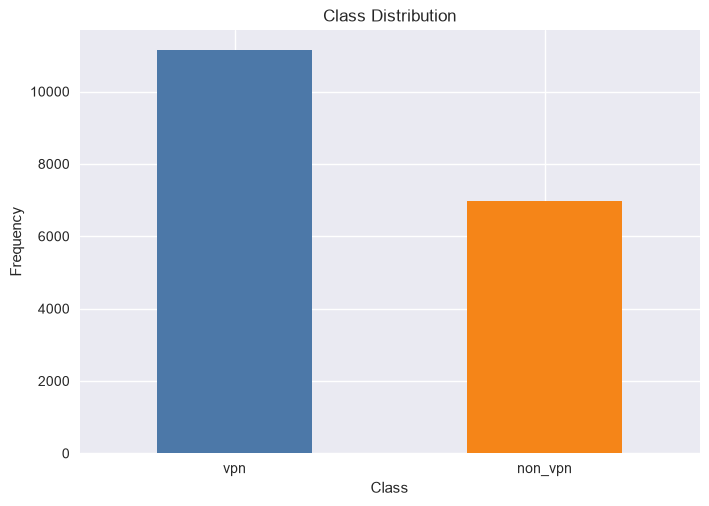

In [14]:
import matplotlib.pyplot as plt
classes = raw_data['Label'].value_counts()
classes.plot(kind = 'bar',rot = 0, color=['#4C78A8', '#F58518'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()


In [15]:
cleaned_data = raw_data.dropna(axis=0).copy()
data_useful_feat = cleaned_data[cleaned_data.columns[7:]].copy()
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data_useful_feat['Label']= label_encoder.fit_transform(data_useful_feat['Label'])
data_useful_feat.head()


,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,774.0,0.0,2.0,0.0,218.0,0.0,0.0,0.0,0.000000,185.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,634204.0,5.0,5.0,196.0,180.0,152.0,0.0,39.2,65.872604,104.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,903.0,0.0,2.0,0.0,175.0,0.0,0.0,0.0,0.000000,141.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,207853.0,0.0,2.0,0.0,443.0,0.0,0.0,0.0,0.000000,346.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,222081.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [16]:
def min_max_scaling(df):
    df_norm = df.copy()
    for column in df_norm.columns:
        if column != 'Label' and pd.api.types.is_numeric_dtype(df_norm[column]):
            df_norm[column] = (df_norm[column] - df_norm[column].min()) / (df_norm[column].max() - df_norm[column].min())
    return df_norm
min_max_scaled = min_max_scaling(data_useful_feat)
min_max_scaled_cleaned = min_max_scaled.dropna(axis=1).copy()
min_max_scaled_cleaned.head()


,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,...,Fwd Act Data Pkts,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.000006,0.000000,0.000032,0.000000,0.000005,0.000000,0.0,0.000000,0.000000,0.008010,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.005285,0.000158,0.000127,0.000005,0.000004,0.056801,0.0,0.030047,0.065277,0.004503,...,0.000063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.000008,0.000000,0.000032,0.000000,0.000004,0.000000,0.0,0.000000,0.000000,0.006105,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.001732,0.000000,0.000032,0.000000,0.000011,0.000000,0.0,0.000000,0.000000,0.014982,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.001851,0.000000,0.000032,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [17]:
corr_features = ['Fwd Pkt Len Min', 'Bwd Pkt Len Max',  'Bwd Pkt Len Mean', 
                  'Bwd Pkt Len Std', 'Pkt Len Mean', 'Pkt Len Std', 'Down/Up Ratio', 
                  'Pkt Size Avg', 'Bwd Seg Size Avg', 'Init Bwd Win Byts', 'Label']
Final_dataframe = min_max_scaled_cleaned[corr_features].copy()
Final_dataframe.head()


,Fwd Pkt Len Min,Bwd Pkt Len Max,Bwd Pkt Len Mean,Bwd Pkt Len Std,Pkt Len Mean,Pkt Len Std,Down/Up Ratio,Pkt Size Avg,Bwd Seg Size Avg,Init Bwd Win Byts,Label
0,0.0,0.008010,0.038076,0.033726,0.056290,0.035547,0.0,0.083497,0.038076,0.000000,1
1,0.0,0.004503,0.012576,0.015777,0.022997,0.021730,0.2,0.025016,0.012576,0.000458,0
2,0.0,0.006105,0.030566,0.023741,0.046871,0.025023,0.0,0.069525,0.030566,0.000000,1
3,0.0,0.014982,0.077375,0.055249,0.121102,0.058231,0.0,0.179634,0.077375,0.000000,1
4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.005356,1
